In [1]:
%load_ext autoreload
%autoreload 2

import h5py
import glob
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import skrf as rf
import sys
sys.path.append('../src/')
from rf_calculation import CapacitorAnalysis
from rf_figures import FigureGenerator
from utils import save_dict_to_hdf5, load_dict_from_hdf5

## setup parameters and calculate

In [2]:
params = {'VoltMax': 200, 'VoltStep': 2, 'DispIndex': 100, 'IDC_gap': 3e-4, 'CF': 0}
params['VoltMid'] = int(params['VoltMax'] / params['VoltStep'])
params['V'] = np.arange(-params['VoltMax'], params['VoltMax'] + params['VoltStep'], params['VoltStep'])
params['N'] = len(params['V'])
# params['Eff'] = (params['V'] / params['IDC_gap']) / 1000

files_dict = {}
for k in range(params['VoltMid'], params['N']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_{params["V"][k]}V_dev.s2p'
        files_dict[File] = k
for k in range(params['VoltMid']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_N{params["V"][params["N"]-1-k]}V_dev.s2p'
        files_dict[File] = k
files_dict

{'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_0V_dev.s2p': 100,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_2V_dev.s2p': 101,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_4V_dev.s2p': 102,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_6V_dev.s2p': 103,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_8V_dev.s2p': 104,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_10V_dev.s2p': 105,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_12V_dev.s2p': 106,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_14V_dev.s2p': 107,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_16V_dev.s2p': 108,
 '../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_18V_dev.s2p': 109,
 '../datasets/L

In [3]:
for k in range(params['VoltMid'], params['N']):
    File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_{params["V"][k]}V_dev.s2p'
    files_dict[File] = k

In [4]:
rf.Network(File)

2-Port Network: 'LYW034BTONSO25nm_0D16F200V2S_J_200V_dev',  10000000.0-26500000000.0 Hz, 2651 pts, z0=[50.+0.j 50.+0.j]

In [22]:
params_calculation

{'Freq': array([1.00000000e+07, 1.99962264e+07, 2.99924528e+07, ...,
        2.64800075e+10, 2.64900038e+10, 2.65000000e+10]),
 'FreqS': array([1.00000000e-02, 1.99962264e-02, 2.99924528e-02, ...,
        2.64800075e+01, 2.64900038e+01, 2.65000000e+01]),
 'w': array([6.28318531e+07, 1.25639996e+08, 1.88448139e+08, ...,
        1.66378794e+11, 1.66441602e+11, 1.66504411e+11]),
 'S11i': array([[-0.00310683, -0.00339565, -0.00340214, ..., -0.00353077,
         -0.00339538, -0.00355592],
        [-0.00233155, -0.00229564, -0.00230491, ..., -0.00235814,
         -0.00225314, -0.0024296 ],
        [-0.00252387, -0.00255322, -0.00255626, ..., -0.00262845,
         -0.00255114, -0.00260642],
        ...,
        [-0.79250252, -0.79240078, -0.79223883, ..., -0.79245114,
         -0.79255748, -0.79259151],
        [-0.79280221, -0.79280847, -0.79263443, ..., -0.79279518,
         -0.79281551, -0.79294121],
        [-0.7930336 , -0.79298604, -0.79291844, ..., -0.79313064,
         -0.79323196, -0

0D16F200V2S_J_186V_dev: 0 degree, 16 fingers, 200V maximum, 2 voltage step, J - index of measurement, 186V - current voltage

LYW034BTONSO25nm: sample number, BTO - thin film composition, NSO - substrate material, 25nm - thickness

In [5]:
params = {'VoltMax': 200, 'VoltStep': 2, 'DispIndex': 100, 'IDC_gap': 3e-4, 'CF': 0}
params['VoltMid'] = int(params['VoltMax'] / params['VoltStep'])
params['V'] = np.arange(-params['VoltMax'], params['VoltMax'] + params['VoltStep'], params['VoltStep'])
params['N'] = len(params['V'])
# params['Eff'] = (params['V'] / params['IDC_gap']) / 1000

files_dict = {}
for k in range(params['VoltMid'], params['N']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_{params["V"][k]}V_dev.s2p'
        files_dict[File] = k     
for k in range(params['VoltMid']):
        File = f'../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_N{params["V"][params["N"]-1-k]}V_dev.s2p'
        files_dict[File] = k

analyzer = CapacitorAnalysis(params)
params_calculation = analyzer.setup_params(files_dict)

# calculation
results = analyzer.run_analysis()
# np.save('LYW034BTONSO25nm_0D16F200V2S_J_Tunability.npy', results['Tunability2D'])
# np.save('LYW034BTONSO25nm_0D16F200V2S_J_QFPeakatFreq.npy', results['QFFiltVolt'])
# print(results['Tunability2D'])
# print(results['QFFiltVolt'])

Setup parameters:


100%|██████████| 201/201 [02:38<00:00,  1.27it/s]


Calculate:


In [3]:
params = {'VoltMax': 200, 'VoltStep': 2, 'DispIndex': 100, 'IDC_gap': 3e-4, 'CF': 0}
analyzer = CapacitorAnalysis(params)
params_calculation = analyzer.setup_params(folder_path='../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/')

# calculation
results = analyzer.run_analysis()
# np.save('LYW034BTONSO25nm_0D16F200V2S_J_Tunability.npy', results['Tunability2D'])
# np.save('LYW034BTONSO25nm_0D16F200V2S_J_QFPeakatFreq.npy', results['QFFiltVolt'])
# print(results['Tunability2D'])
# print(results['QFFiltVolt'])

Setup parameters:


100%|██████████| 201/201 [02:21<00:00,  1.42it/s]


Calculate:


In [4]:
all_results = {}
all_results.update(params)
all_results.update(params_calculation)
all_results.update(all_results)
all_results.update(results)

for key, value in all_results.items():
    print(key)
    if isinstance(value, np.ndarray):
        print('----shape:', value.shape)
    elif isinstance(value, list):
        print('----list:', len(value))
    else:
        print('----value:', value)

VoltMax
----value: 200
VoltStep
----value: 2
DispIndex
----value: 100
IDC_gap
----value: 0.0003
CF
----value: 0
VoltMid
----value: 100
V
----shape: (201,)
N
----value: 201
Freq
----shape: (2651,)
FreqS
----shape: (2651,)
w
----shape: (2651,)
S11i
----shape: (2651, 201)
S12i
----shape: (2651, 201)
S21i
----shape: (2651, 201)
S22i
----shape: (2651, 201)
S11r
----shape: (2651, 201)
S12r
----shape: (2651, 201)
S21r
----shape: (2651, 201)
S22r
----shape: (2651, 201)
Y11i
----shape: (2651, 201)
Y12i
----shape: (2651, 201)
Y21i
----shape: (2651, 201)
Y22i
----shape: (2651, 201)
Y11r
----shape: (2651, 201)
Y12r
----shape: (2651, 201)
Y21r
----shape: (2651, 201)
Y22r
----shape: (2651, 201)
Z11i
----shape: (2651, 201)
Z12i
----shape: (2651, 201)
Z21i
----shape: (2651, 201)
Z22i
----shape: (2651, 201)
Z11r
----shape: (2651, 201)
Z12r
----shape: (2651, 201)
Z21r
----shape: (2651, 201)
Z22r
----shape: (2651, 201)
S11m
----shape: (2651, 201)
S12m
----shape: (2651, 201)
S21m
----shape: (2651, 201)
S2

## save calculation results

In [5]:
save_dict_to_hdf5(all_results, '../datasets/LYW034BTONSO25nm-0D16F200V2S-J-results.h5')

100%|██████████| 58/58 [00:00<00:00, 755.41it/s]


## viz figures

In [6]:
all_results = load_dict_from_hdf5('../datasets/LYW034BTONSO25nm-0D16F200V2S-J-results.h5')

100%|██████████| 58/58 [00:00<00:00, 935.47it/s]


In [7]:
viz_params = {'VoltMax': 200, 'VoltStep': 2, 'DispIndex': 100, 'IDC_gap': 3e-4, 'CF': 0,
              'BVI': 101, 'FM': 26.5, 'FT': 32, 'LW': 1, 'QFSL': 10, 'QFSH': 10000, 'Cap3DL': 0.05, 'Cap3DH': 0.1,
              'TunL': 1, 'TunH': 2, 'LTmin': 0.01, 'LTmax': 0.5, 'S11min': -5, 'S11max': 0, 'S21min': -30, 'S21max': 0}
all_results.update(viz_params)
figure_generator = FigureGenerator(params=all_results, figsize=(5,4), cmap='viridis')

FigureGenerator: Initialized


In [8]:
print(all_results.keys())

dict_keys(['CF', 'CQF', 'C_fit', 'Capacitance0Volt', 'Capacitance3D', 'CapacitanceMin', 'Cf_fitted', 'Cmax_fitted', 'DiffConductance3D', 'DispIndex', 'Freq', 'FreqS', 'IDC_gap', 'LossTan', 'N', 'QFFiltVolt', 'QFMF', 'QualityFactor', 'S11i', 'S11m', 'S11r', 'S12i', 'S12m', 'S12r', 'S21i', 'S21m', 'S21r', 'S22i', 'S22m', 'S22r', 'Tunability2D', 'Tunability3D', 'V', 'V_fit', 'V_half_fitted', 'Vh', 'VoltMax', 'VoltMid', 'VoltStep', 'Y11Conductance3D', 'Y11i', 'Y11r', 'Y12Conductance3D', 'Y12i', 'Y12r', 'Y21i', 'Y21r', 'Y22i', 'Y22r', 'Z11i', 'Z11r', 'Z12i', 'Z12r', 'Z21i', 'Z21r', 'Z22i', 'Z22r', 'w', 'BVI', 'FM', 'FT', 'LW', 'QFSL', 'QFSH', 'Cap3DL', 'Cap3DH', 'TunL', 'TunH', 'LTmin', 'LTmax', 'S11min', 'S11max', 'S21min', 'S21max'])


## Qfactor

c:\Users\yig319\LU Student Dropbox\Yichen Guo\RF_measurement\notebooks\../src\rf_figures.py:144: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, np.max(QualityFactor))


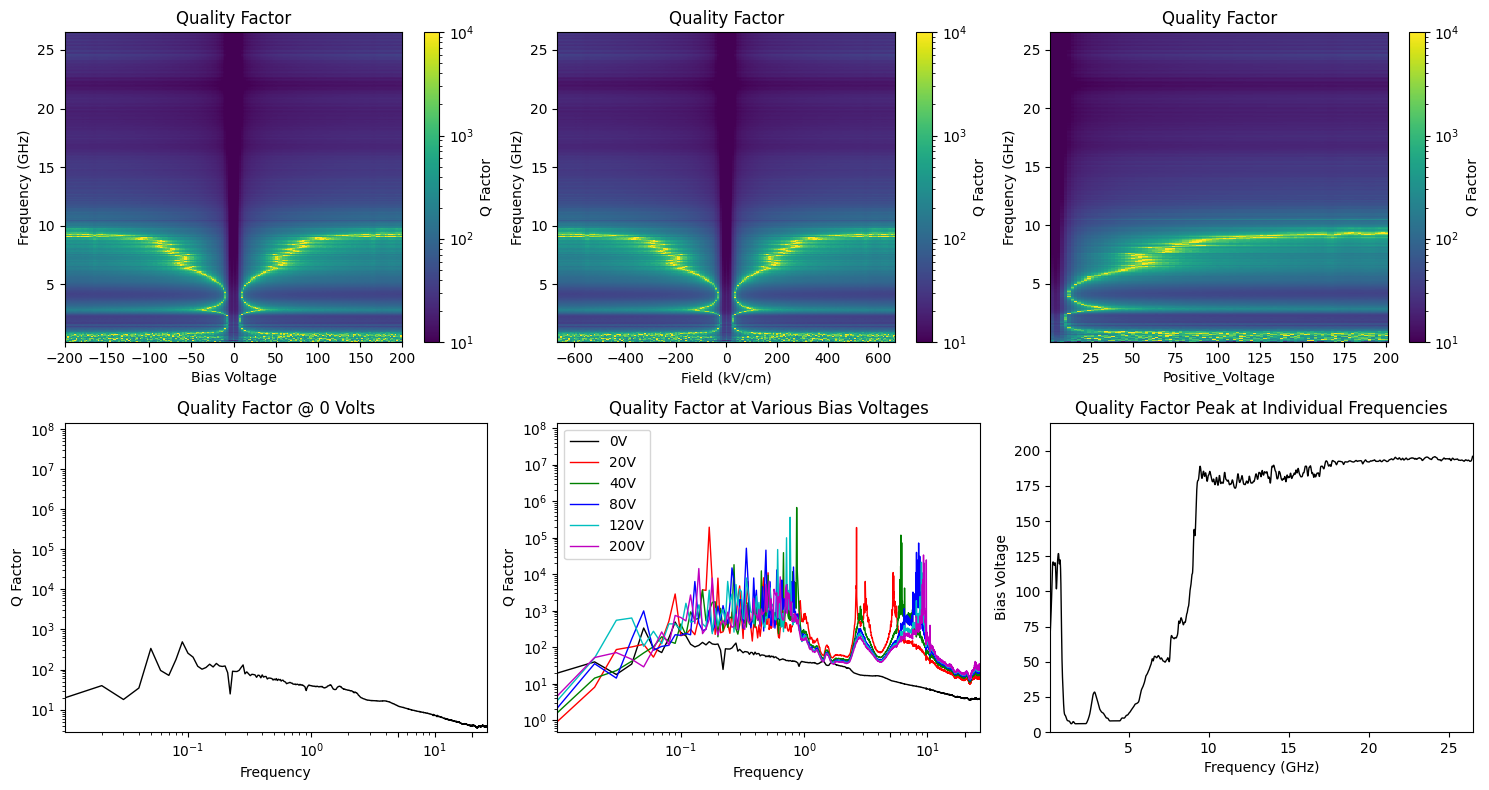

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['QualityFactor'], plot_type='2d', title='Quality Factor', 
                              z_label='Q Factor', z_scale='log', xlim=(-all_results['VoltMax'], all_results['VoltMax']), 
                              ylim=(0.1, all_results['FM']), zlim=(all_results['QFSL'], all_results['QFSH']), ax=axes[0, 0])

E_Field = (all_results['V'] / all_results['IDC_gap']) / 1000
figure_generator.plot_heatmap(E_Field, all_results['FreqS'], all_results['QualityFactor'], plot_type='2d', title='Quality Factor', x_label='Field (kV/cm)', z_label='Q Factor', z_scale='log', 
                              xlim=(-(all_results['VoltMax']/all_results['IDC_gap'])/1000, (all_results['VoltMax']/all_results['IDC_gap'])/1000), 
                              ylim=(0.1, all_results['FM']), zlim=(all_results['QFSL'], all_results['QFSH']), ax=axes[0, 1])

figure_generator.plot_heatmap(all_results['Vh'][1:], all_results['FreqS'], all_results['QFMF'].transpose(), plot_type='2d', title='Quality Factor', x_label='Positive_Voltage', z_label='Q Factor', z_scale='log',
                              zlim=(all_results['QFSL'], all_results['QFSH']), ax=axes[0, 2])

figure_generator.Qfactor_lineplot(all_results['FreqS'], all_results['QualityFactor'], ax=axes[1, 0])
bias_voltages = [(0, all_results['BVI']), (20, 110), (40, 120), (80, 140), (120, 160), (200, 200)]
figure_generator.Qfactor_lineplot(all_results['FreqS'], all_results['QualityFactor'], bias_voltages, ax=axes[1, 1])
figure_generator.Qfactor_peak_lineplot(all_results['FreqS'], all_results['QFFiltVolt'], ax=axes[1, 2])

plt.tight_layout()
plt.show()

## capacitance and conductance

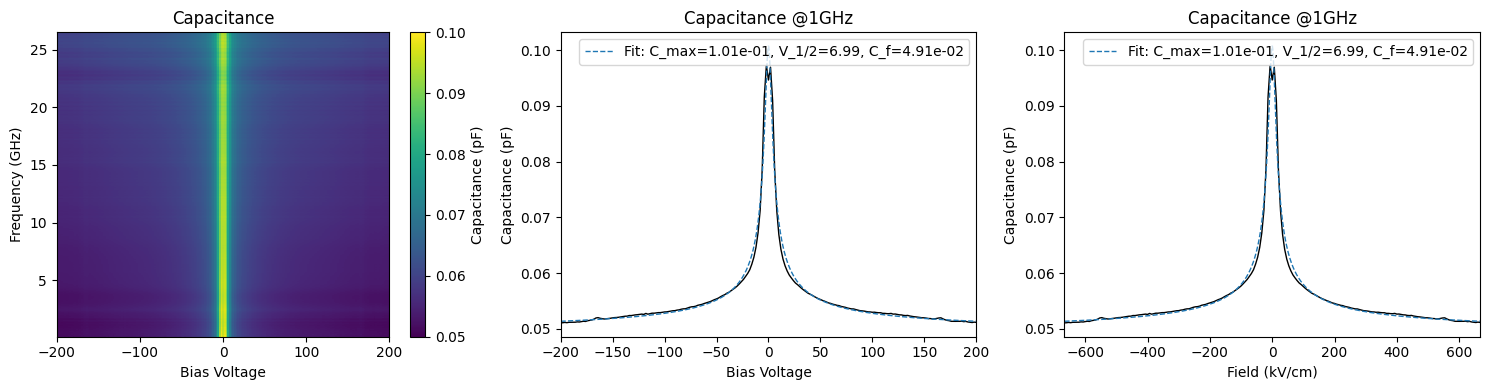

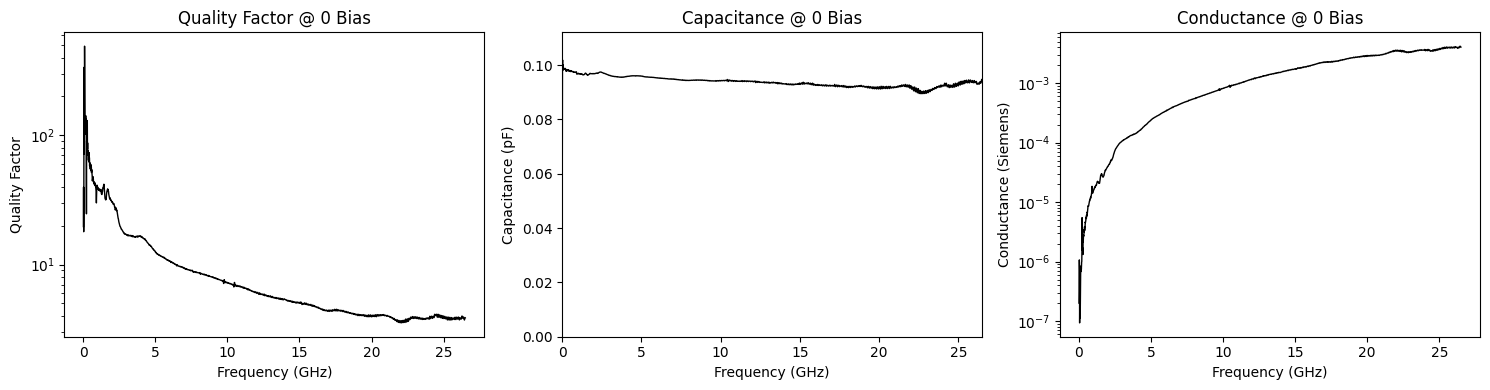

In [10]:
# figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'],all_results['Capacitance3D'], plot_type='3d', title='Capacitance', z_label='Capacitance (pF)', 
#                               xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), zlim=(all_results['Cap3DL'], all_results['Cap3DH']), figsize=(8,6))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'],all_results['Capacitance3D'], plot_type='2d', title='Capacitance', z_label='Capacitance (pF)', 
                              xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), zlim=(all_results['Cap3DL'], all_results['Cap3DH']), ax=axes[0])

figure_generator.capacitance_lineplot(all_results['V'], all_results['FreqS'], all_results['Capacitance3D'], xaxis='voltage', fit_params=all_results, ax=axes[1])
figure_generator.capacitance_lineplot(all_results['V'], all_results['FreqS'], all_results['Capacitance3D'], xaxis='field', fit_params=all_results, ax=axes[2])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
figure_generator.plot_lineplot(all_results['FreqS'], np.abs(all_results['QualityFactor'][:, all_results['BVI']]), 
                               x_label='Frequency (GHz)', y_label='Quality Factor', title='Quality Factor @ 0 Bias', y_scale='log', ax=axes[0])
figure_generator.capacitance_lineplot(all_results['V'], all_results['FreqS'],all_results['Capacitance3D'], xaxis='frequency', ax=axes[1])
figure_generator.plot_lineplot(all_results['FreqS'], np.abs(all_results['Y12r'][:, all_results['BVI']]), 
                               x_label='Frequency (GHz)', y_label='Conductance (Siemens)', title='Conductance @ 0 Bias', y_scale='log', ax=axes[2])
plt.tight_layout()
plt.show()

# figure_generator.compare_conductance_capacitance(all_results['FreqS'],all_results['QualityFactor'],all_results['Capacitance3D'], all_results['Y12r'])

## Tunibility

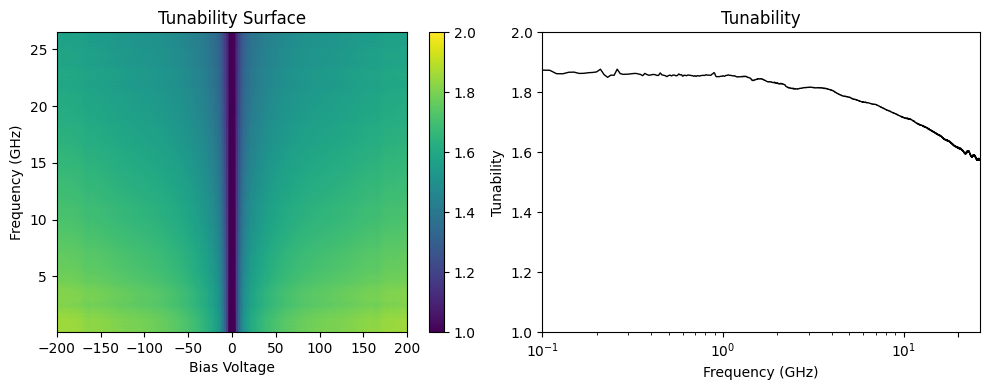

In [11]:
# figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], results['Tunability3D'], plot_type='3d', title='Tunability Surface', 
#                               xlim=(-params['VoltMax'], params['VoltMax']), ylim=(0.1, all_results['FM']), zlim=(all_results['TunL'], all_results['TunH']), figsize=(8,6))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['Tunability3D'], plot_type='2d', title='Tunability Surface', 
                              xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), zlim=(all_results['TunL'], all_results['TunH']), ax=axes[0])
figure_generator.plot_lineplot(all_results['FreqS'], all_results['Tunability2D'], x_label='Frequency (GHz)', y_label='Tunability', 
                               title='Tunability', x_scale='log', xlim=(0.1, all_results['FM']), ylim=(all_results['TunL'], all_results['TunH']), 
                               xticks=[0.1, 1, 10, 20], ax=axes[1])
plt.tight_layout()
plt.show()

## other figures

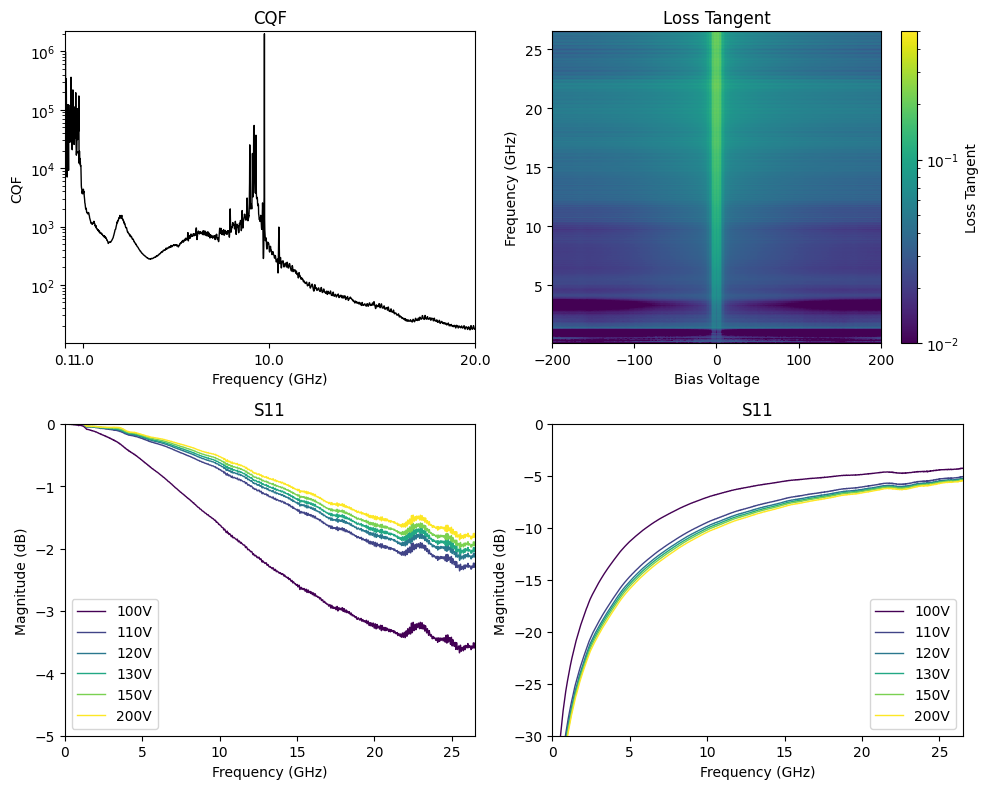

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
figure_generator.plot_lineplot(all_results['FreqS'], all_results['CQF'], x_label='Frequency (GHz)', y_label='CQF', title='CQF', 
                               y_scale='log', xlim=(0.1, 20), ylim=(min(all_results['CQF'])/1.1, max(all_results['CQF'])*1.1), xticks=[0.1, 1, 10, 20], ax=axes[0, 0])
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['LossTan'], plot_type='2d', title='Loss Tangent', z_label='Loss Tangent', z_scale='log', 
                              xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), zlim=(all_results['LTmin'], all_results['LTmax']), ax=axes[0, 1])
# figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], results['LossTan'], plot_type='3d', title='Loss Tangent', 
#                               xlim=(-params['VoltMax'], params['VoltMax']), ylim=(0.1, all_results['FM']), zlim=(all_results['LTmin'], all_results['LTmax']), figsize=(8,6))
voltages = [100, 110, 120, 130, 150, 200]
figure_generator.s_parameter_lineplot(all_results['FreqS'], all_results['S11m'], voltages, 'S11', ylim=(all_results['S11min'], all_results['S11max']), ax=axes[1, 0])
figure_generator.s_parameter_lineplot(all_results['FreqS'], all_results['S21m'], voltages, 'S11', ylim=(all_results['S21min'], all_results['S21max']), ax=axes[1, 1])
plt.tight_layout()
plt.show()
# figure_generator.s_parameters_lineplot(all_results['FreqS'], all_results['S11m'], all_results['S21m'], voltages,
#                                        all_results['S11min'], all_results['S11max'], all_results['S21min'], all_results['S21max'])

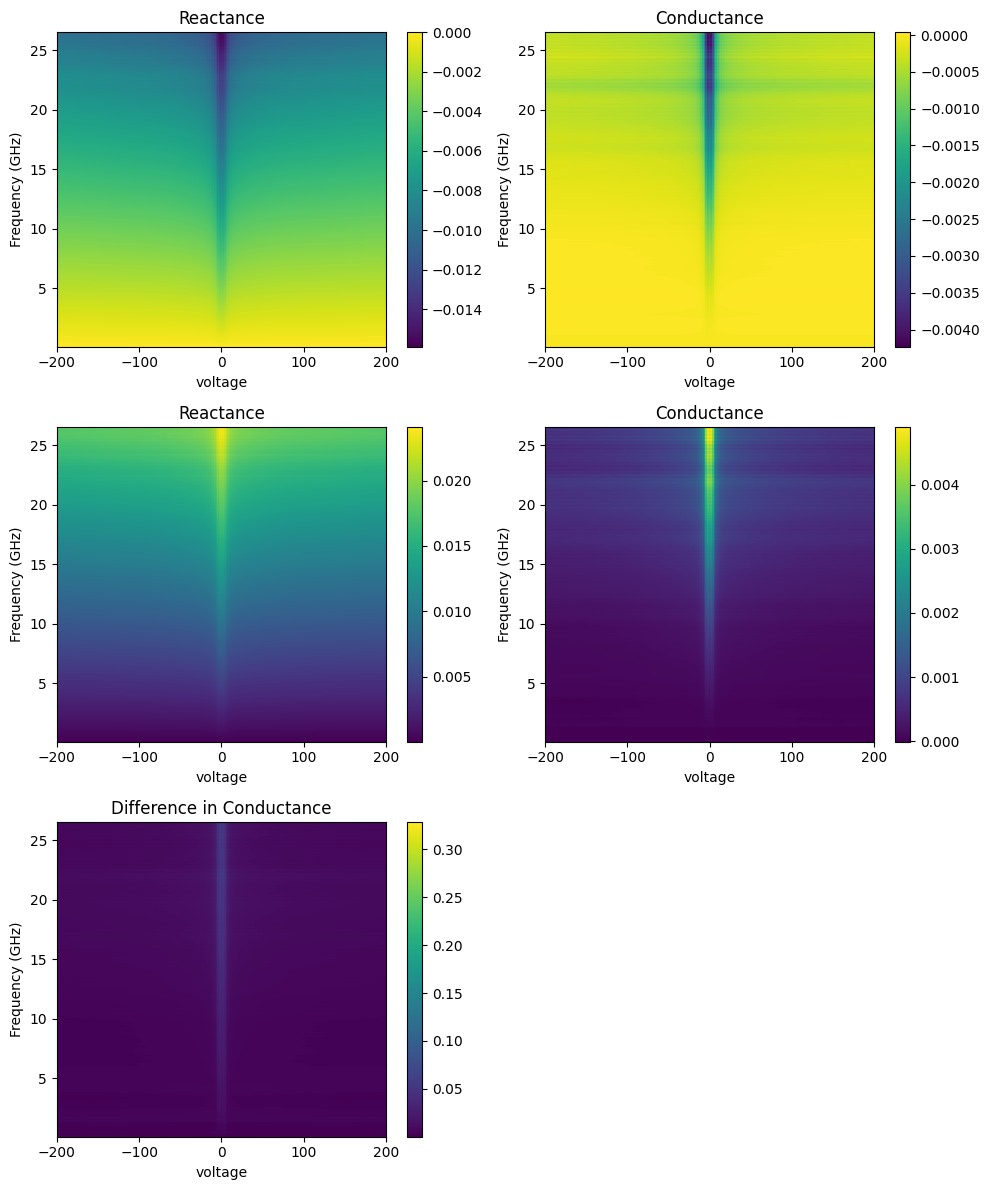

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['Y12i'], plot_type='2d', title='Reactance', x_label='voltage', 
                              z_scale='log', xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), ax=axes[0, 0])
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['Y12r'], plot_type='2d', title='Conductance', x_label='voltage', 
                              z_scale='log', xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), ax=axes[0, 1])
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['Y11i'], plot_type='2d', title='Reactance', x_label='voltage', 
                              z_scale='log', xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), ax=axes[1, 0])
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['Y11r'], plot_type='2d', title='Conductance', x_label='voltage', 
                              z_scale='log', xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), ax=axes[1, 1])
figure_generator.plot_heatmap(all_results['V'], all_results['FreqS'], all_results['DiffConductance3D'], plot_type='2d', title='Difference in Conductance', x_label='voltage', 
                              z_scale='log', xlim=(-all_results['VoltMax'], all_results['VoltMax']), ylim=(0.1, all_results['FM']), ax=axes[2, 0])
fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()